In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

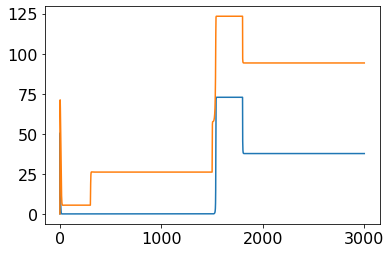

[[2.3474e-04 2.6062e+01]
 [3.7674e+01 9.4217e+01]]


In [3]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

low state vars =  [ 8.3127e-005  2.5847e+001 -3.3072e-001  1.0327e+000  0.0000e+000
  1.6420e-005  7.9023e-001  1.5346e-005  8.7951e-001  1.0135e-006
  2.5945e-003  8.8534e-007  1.9317e-003  2.3986e-264  1.7990e-264
  1.5030e+000  1.4869e+000 -7.0969e+001  2.1153e+001  2.3058e+000]


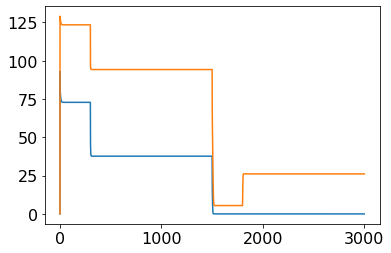

In [4]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.99

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [56]:
dur = 15.
dur_pre = 5.
dur_post = 5.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_lh = aln.getZeroTarget()
target_lh[:,0,:] = steady_rates[1,0]
target_lh[:,1,:] = steady_rates[1,1] 

max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 100.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

plot_only = False

init_1nA_lh = control0.copy()
init_1nA_lh[:,0,:40] = 5.
init_1nA_lh[:,1,:40] = 2.

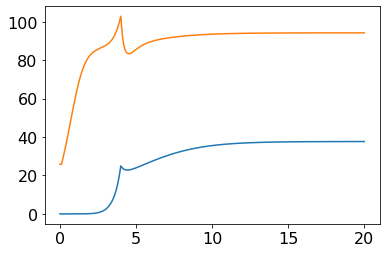

In [49]:
aln.params.duration = dur+dur_pre+dur_post
testC = aln.getZeroControl()
testC[:,0,:40] = 5.
testC[:,1,:40] = 2.
setinitvars(low_state_vars)
aln.run(control = testC)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

In [51]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,0] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                
opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

set cost params


In [8]:
setinitvars(low_state_vars)
max_it = 1
alg = "A1"
#control0
#init_1nA_lh

if not plot_only:
    if alg == "A1":
        bestControlH, bestStateH, costH, runtimeH, grad = aln.A1(init_1nA_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlH, bestStateH, costH, runtimeH = aln.A2(control0, target_lh, max_iteration_ = max_it,
                    tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultH = {"Opt_control": bestControlH,
              "Opt_state": bestStateH,
              "costArray": costH,
              "runtimeArray": runtimeH,    
    }

    dump_dicts = [opt_params, aln.params, resultH]
    filename = str("H_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

RUN  0 , total integrated cost =  5893.69091701457


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4955.89453259511
Improved over  1  iterations by  15.91186910925586  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([45], dtype=int64)) 83.99048774673521
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([25], dtype=int64)) -1509.9097121404357
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663


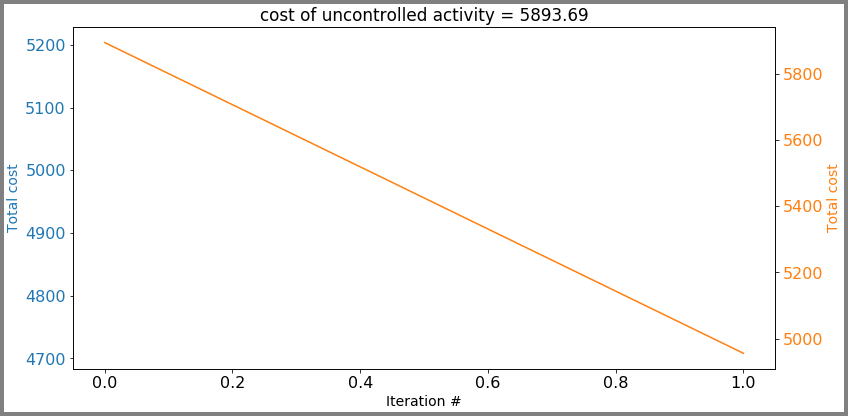

In [9]:
plotFunc.plot_convergence(costH, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )

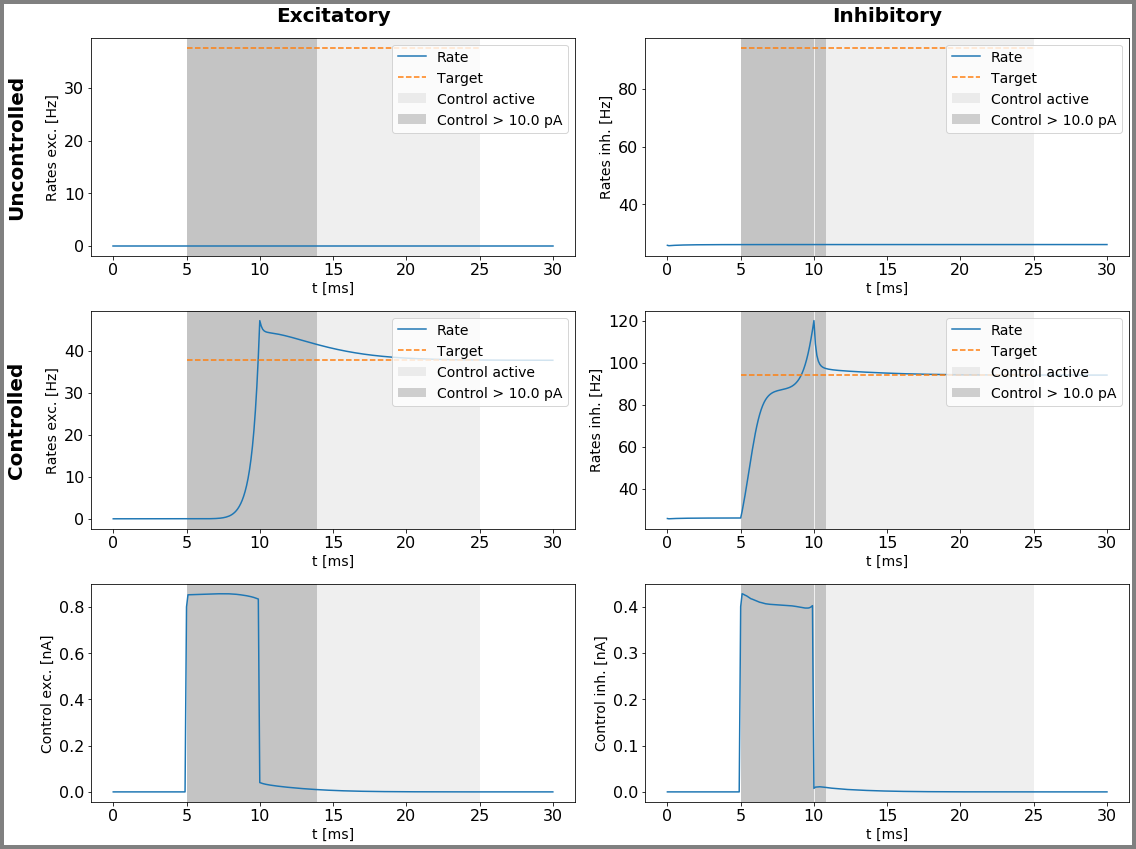

In [10]:
plotFunc.plot_control(aln, bestControlH, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg))

In [57]:
cntrl1 = init_1nA_lh
alg = "A1"

max_it = 10
loop_it = 5
costA1 = np.zeros(max_it*loop_it + 1)
runtimeA1 = np.zeros(max_it*loop_it + 1)

RUN  0 , total integrated cost =  4789.07663505766
step size =  0.0012510521859220095 4119.985239734416
RUN  1 , total integrated cost =  4119.985239734416
step size =  0.0008701874188414376 3874.1528368554455
RUN  2 , total integrated cost =  3874.1528368554455
step size =  0.0013535774478454167 3746.3348046981982
RUN  3 , total integrated cost =  3746.3348046981982
step size =  0.0008544854763486168 3668.9210197268317
RUN  4 , total integrated cost =  3668.9210197268317
step size =  0.001292521085485699 3623.202145996974
RUN  5 , total integrated cost =  3623.202145996974
step size =  0.000797491835841646 3600.221846900822
RUN  6 , total integrated cost =  3600.221846900822
step size =  0.001412411081009264 3585.096140701772
RUN  7 , total integrated cost =  3585.096140701772
step size =  0.0008990561495056361 3577.920329522629
RUN  8 , total integrated cost =  3577.920329522629
step size =  0.0014428376411866077 3571.8008767684546
RUN  9 , total integrated cost =  3571.8008767684546

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.000897608486363616 3566.805391529252
RUN  10 , total integrated cost =  3566.805391529252
Improved over  10  iterations by  25.522064829386295  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([53], dtype=int64)) 47.412316385374304
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -365.85480064073937
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  3566.807390970253
step size =  0.0014836503906836627 3562.3890248328184
RUN  1 , total integrated cost =  3562.3890248328184
step size =  0.0007678859159752348 3559.282767593839
RUN  2 , total 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0006243615199595791 3542.3894418107366
RUN  10 , total integrated cost =  3542.3894418107366
Improved over  10  iterations by  0.6845883862788043  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([47], dtype=int64)) 30.56131937461261
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -359.665464461265
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  3542.38944988594
step size =  0.007795058976465048 3540.4541430652343
RUN  1 , total integrated cost =  3540.4541430652343
step size =  0.0006061762329704651 3538.9761560859083
RUN  2 , total i

...

step size =  0.0008366018226941057 3534.7688319171493
RUN  10 , total integrated cost =  3534.7688319171493
Improved over  10  iterations by  0.21512648670055512  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([45], dtype=int64)) 12.262020639429522
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -356.7365352711489
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  3534.76898750169
step size =  0.001864634479602077 3534.621942385283
RUN  1 , total integrated cost =  3534.621942385283
step size =  0.0008122347793146658 3534.4844259171073
RUN  2 , total 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0007168885960411877 3533.4031261297914
RUN  10 , total integrated cost =  3533.4031261297914
Improved over  10  iterations by  0.038640753518208726  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([44], dtype=int64)) 11.172827437103159
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -357.39449022887857
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663
RUN  0 , total integrated cost =  3533.40325529416
step size =  0.003128241146361548 3533.2567079827186
RUN  1 , total integrated cost =  3533.2567079827186
step size =  0.0006768623160955539 3533.120089143345
RUN  2 , tot

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  0.0006013834010731145 3531.692552019752
RUN  10 , total integrated cost =  3531.692552019752
Improved over  10  iterations by  0.04841517230859438  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([44], dtype=int64)) 9.650097112996281
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -358.01416134281925
Problem in initial value trasfer for  sigmae_f
1.518235957096325
1.5182355652160797
Problem in initial value trasfer for  sigmai_f
1.501909936524541
1.5019098897679062
Problem in initial value trasfer for  tau_exc
21.356780408292302
21.356841639083466
Problem in initial value trasfer for  tau_inh
2.33029094029334
2.330218472786663


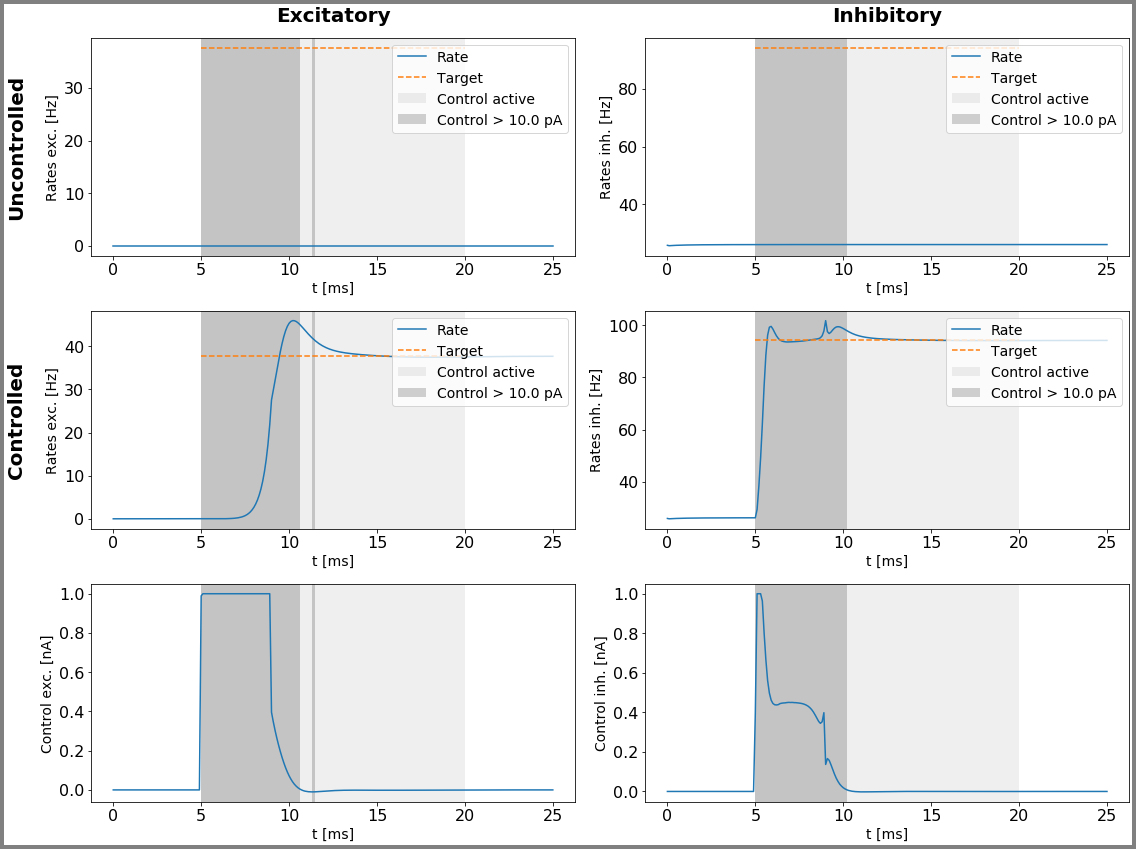

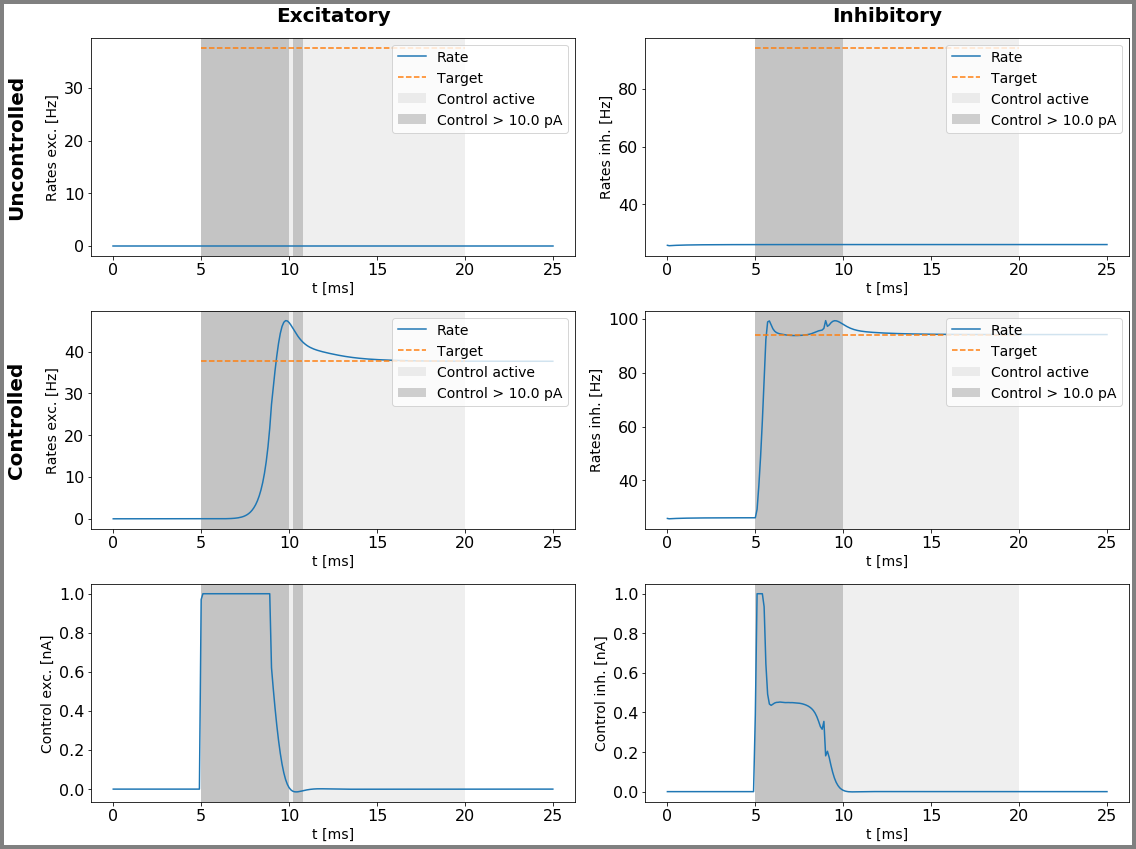

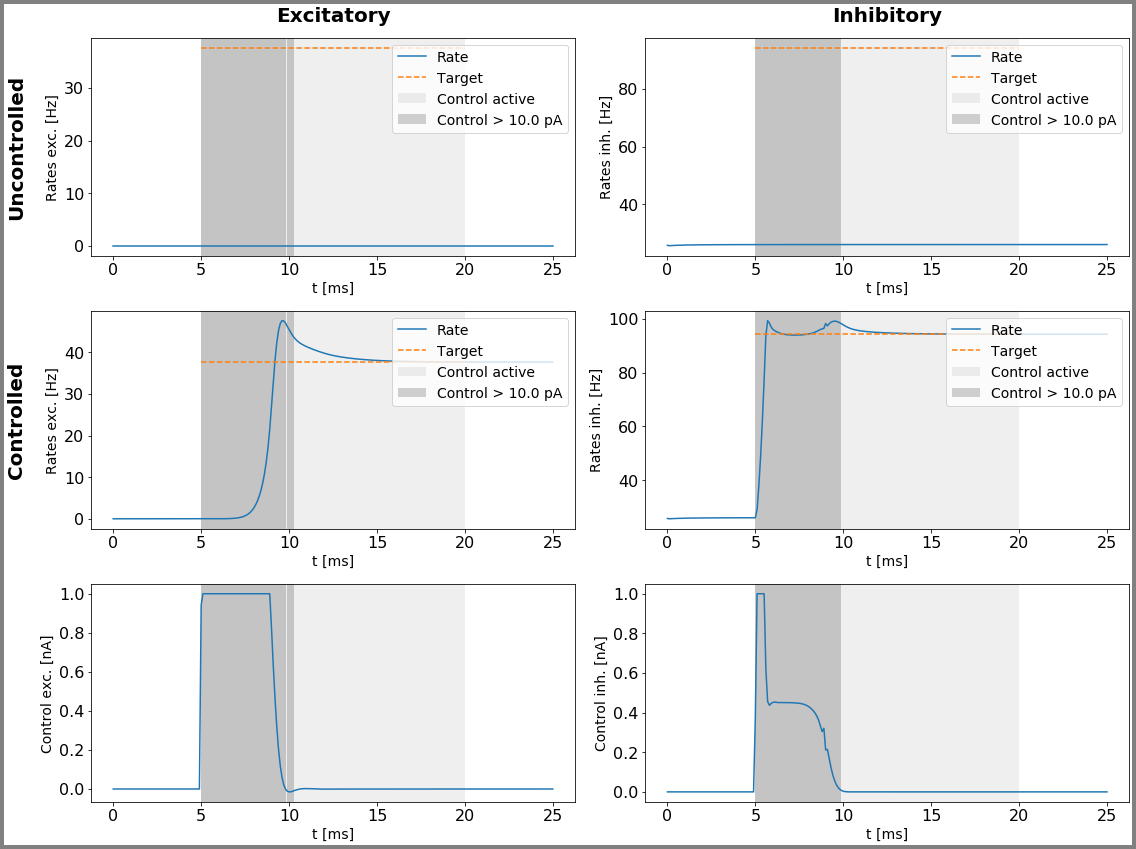

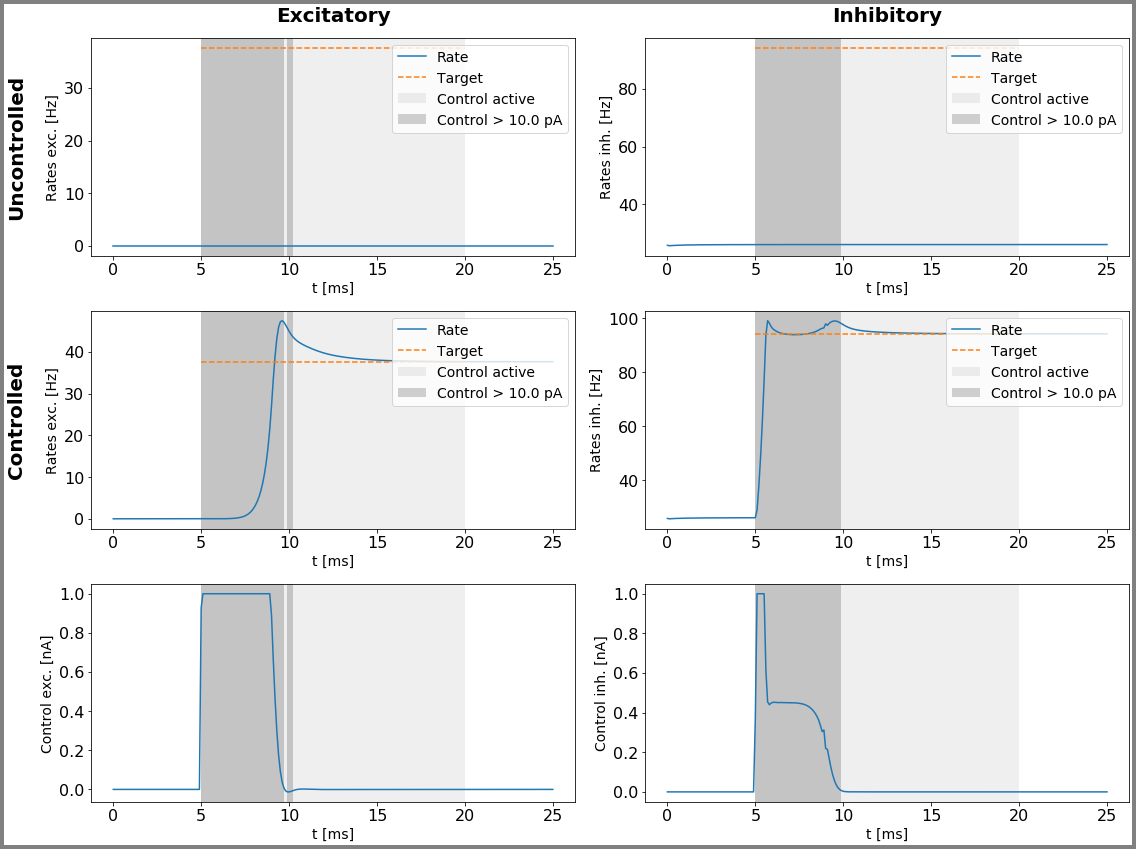

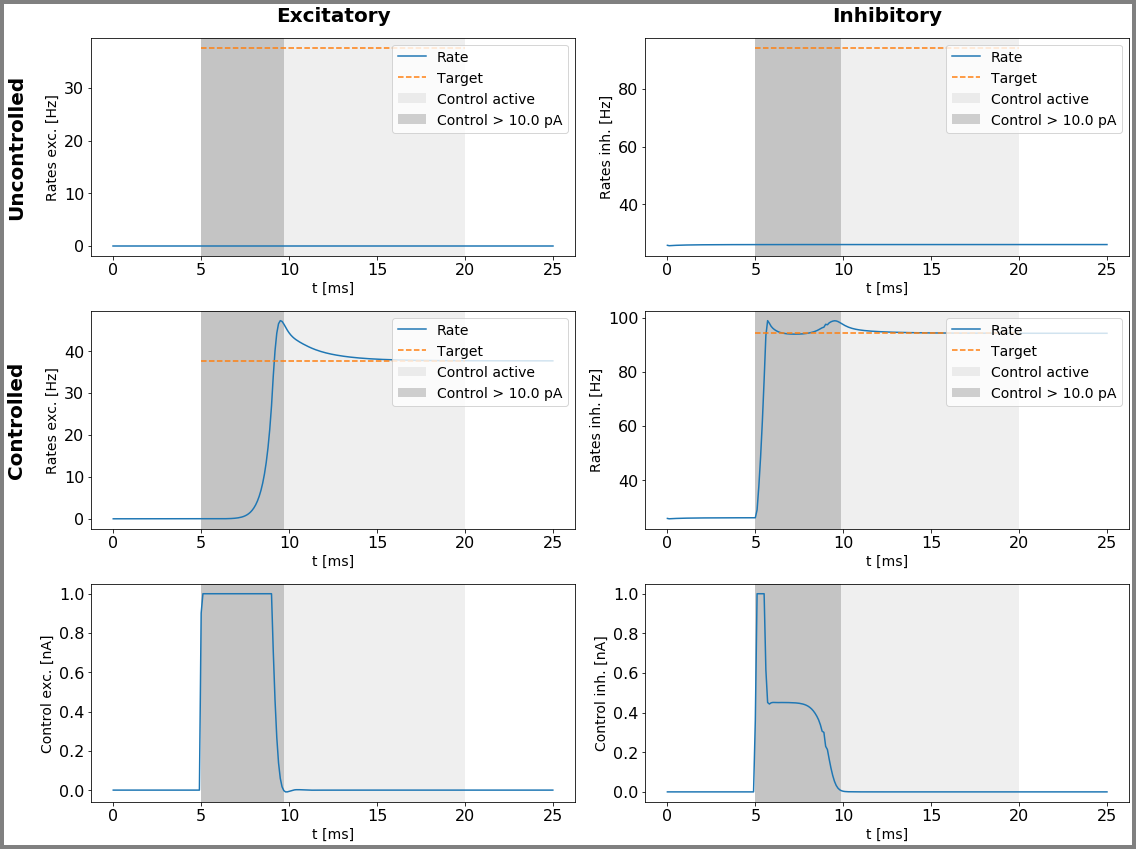

In [58]:
for i in range(loop_it):
    setinitvars(low_state_vars)
    
    cntrlA1_, bestStateA1_, costA1_, runtimeA1_, grad = aln.A1(cntrl1, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA1_, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA1_[:,:,50:201]
    if i == 0:
        costA1[0] = costA1_[0]
    costA1[max_it*i+1:max_it*i+max_it+1] = costA1_[1:]
    runtimeA1[max_it*i+1:max_it*i+max_it+1] = runtimeA1[max_it*i] + runtimeA1_[1:]

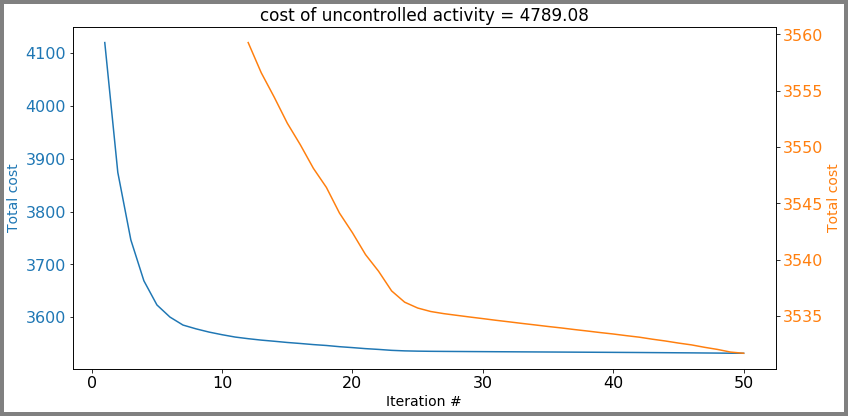

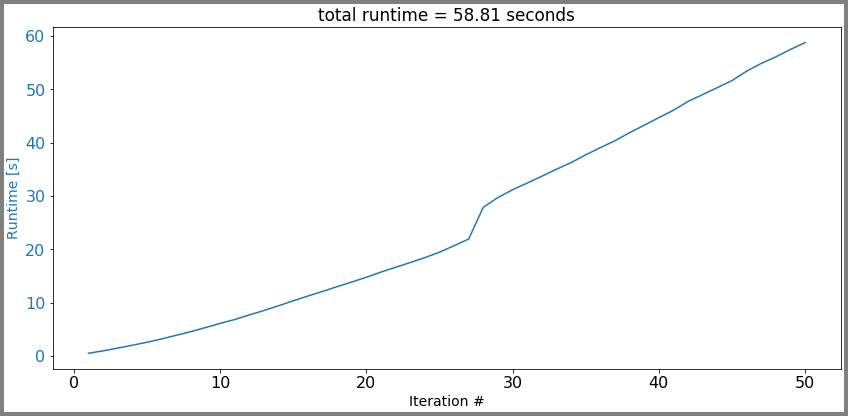

In [59]:
#print(costA1)
#print(costD)
costA1 = np.array(costA1[:])
#print(runtimeA1)
runtimeA1 = np.array(runtimeA1[:])
plotFunc.plot_convergence(costA1, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )
plotFunc.plot_runtime(runtimeA1, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg))

In [16]:
cntrl1 = init_1nA_lh
alg = "A2"

max_it = 5
loop_it = 5
costA2 = np.zeros(max_it*loop_it + 1)
runtimeA2 = np.zeros(max_it*loop_it + 1)

True
RUN  0 , total integrated cost:  3782.9110443088957
RUN  1 , total integrated cost:  3727.4206045346555
RUN  2 , total integrated cost:  3678.5223386308935
RUN  3 , total integrated cost:  3634.224808865925
RUN  4 , total integrated cost:  3597.6838740357457
RUN  5 , total integrated cost:  3571.0471850825115
Improved over  5  iterations by  6  percent.
True
RUN  0 , total integrated cost:  3571.0471850825115
RUN  1 , total integrated cost:  3553.8970629380638
RUN  2 , total integrated cost:  3543.373817494435
RUN  3 , total integrated cost:  3537.1501166700746
RUN  4 , total integrated cost:  3533.886995179245
RUN  5 , total integrated cost:  3532.295091877592
Improved over  5  iterations by  2  percent.
True
RUN  0 , total integrated cost:  3532.295091877592
RUN  1 , total integrated cost:  3531.6209919143093
RUN  2 , total integrated cost:  3531.374725173807
RUN  3 , total integrated cost:  3531.274780906027
RUN  4 , total integrated cost:  3531.199118522812
RUN  5 , total inte

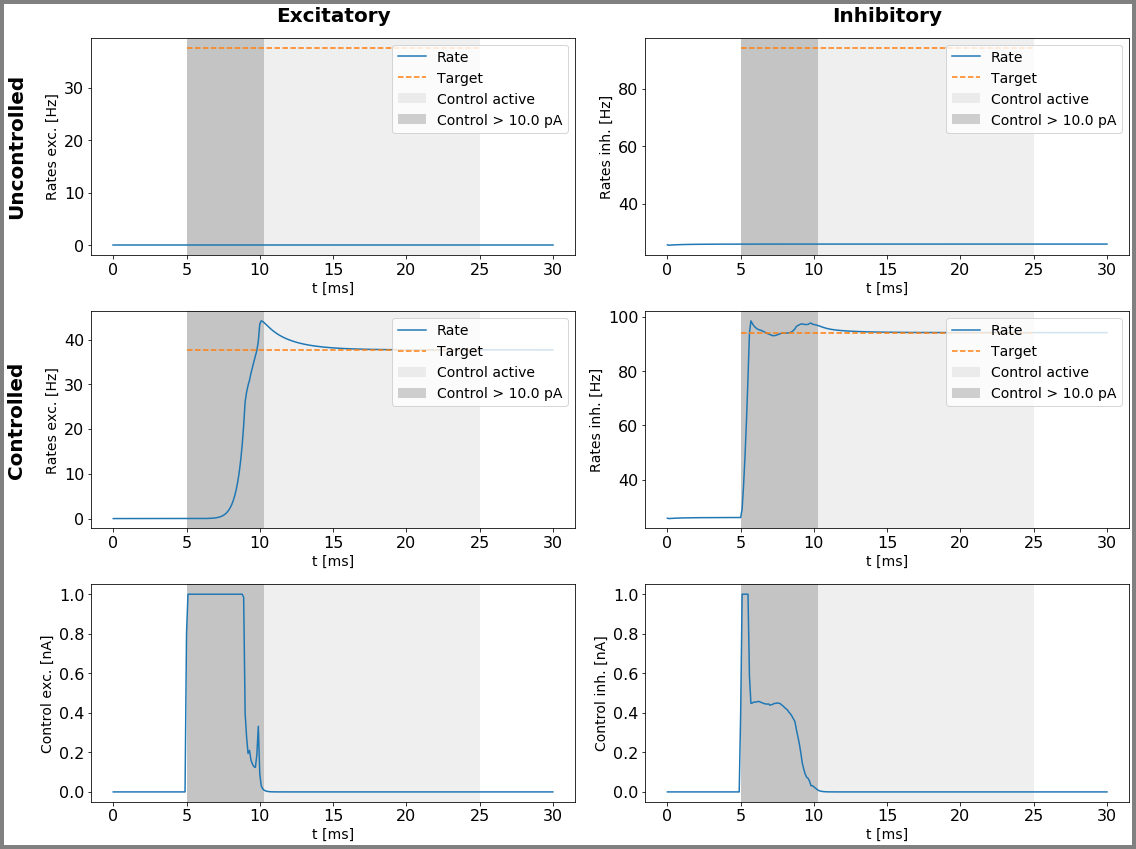

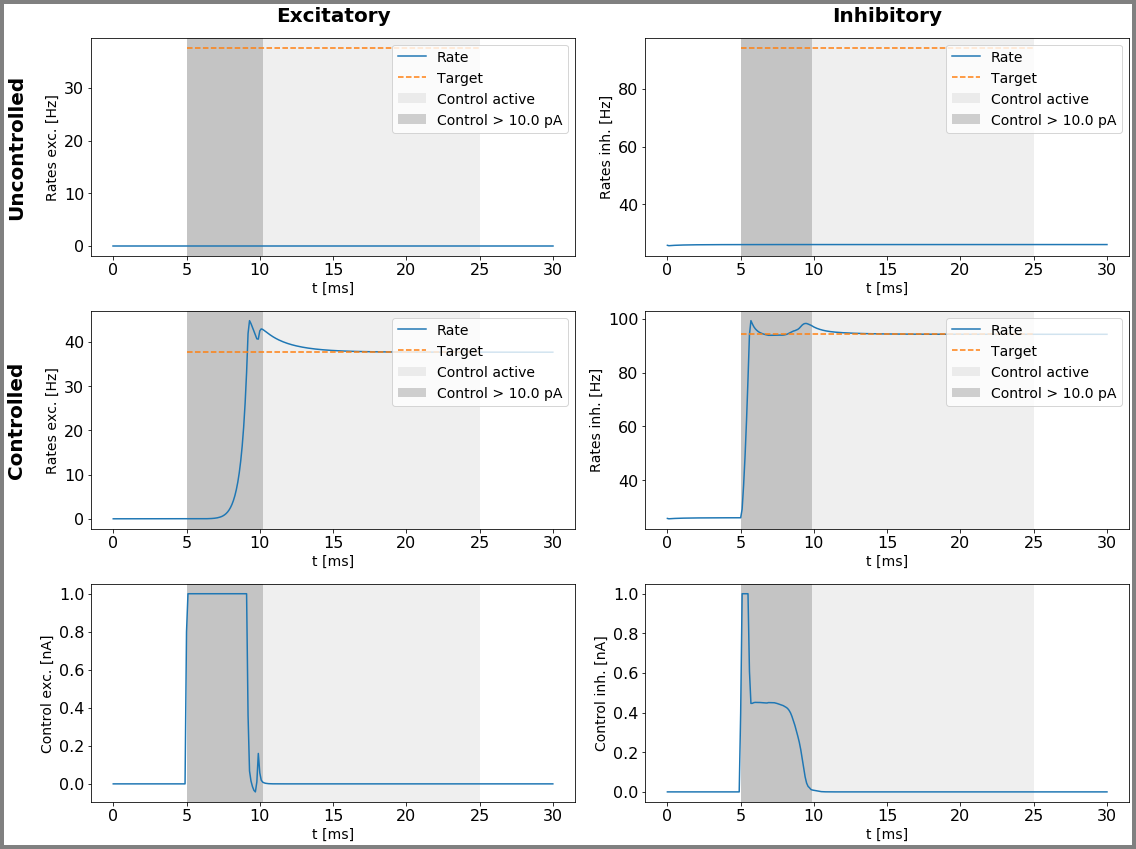

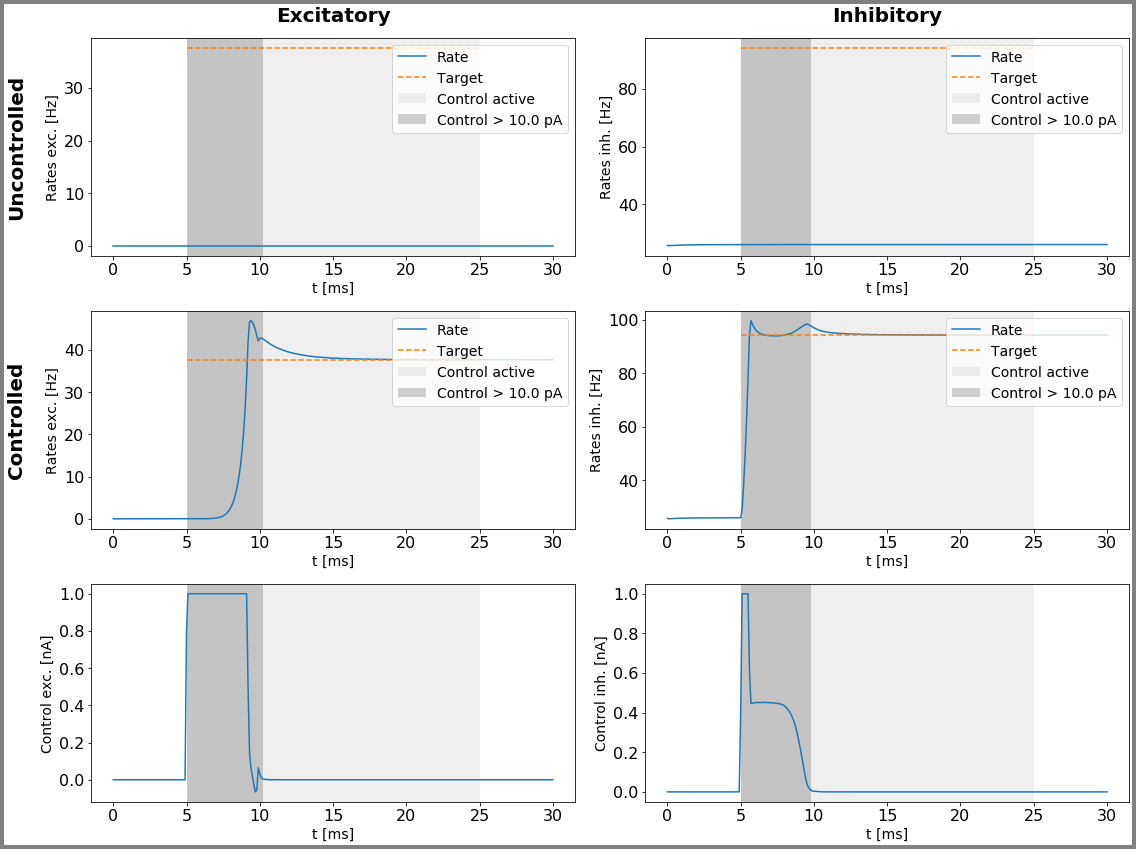

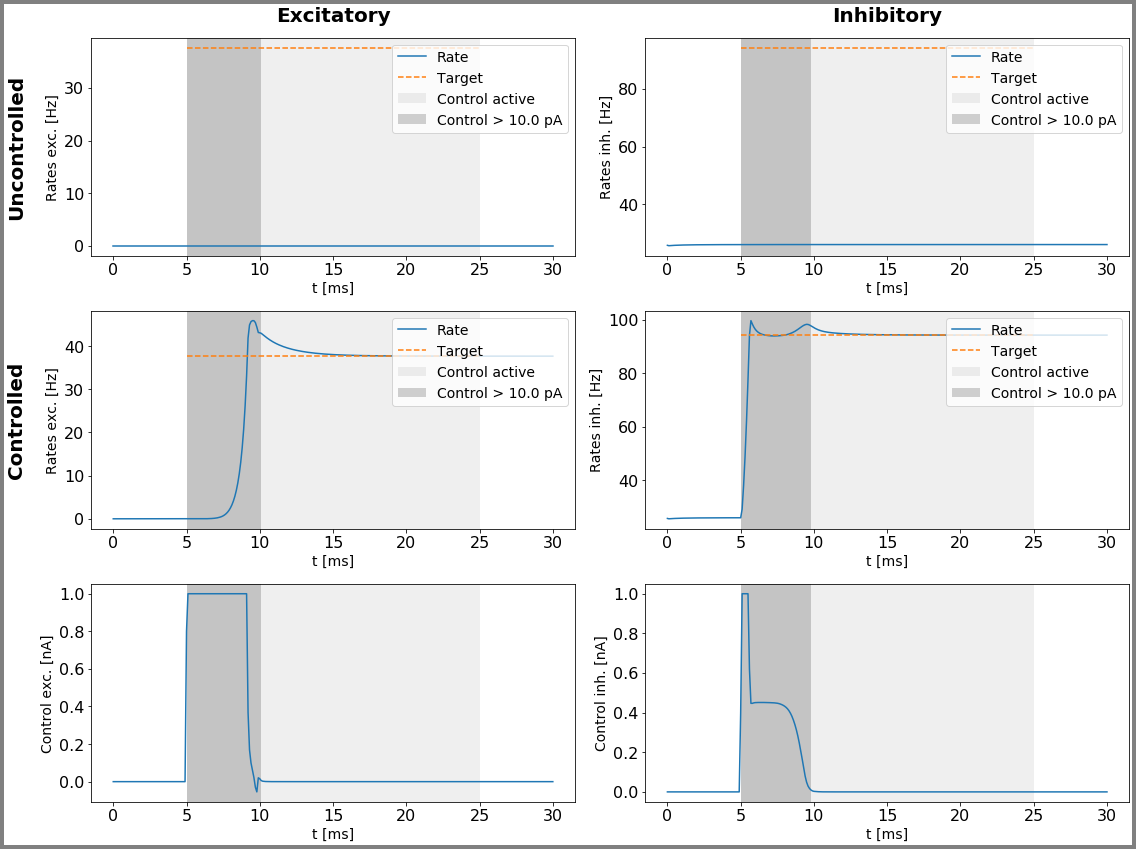

In [17]:
for i in range(loop_it):
    setinitvars(low_state_vars)
    cntrlA2_, bestStateA2_, costA2_, runtimeA2_ = aln.A2(cntrl1, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA2_, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA2_[:,:,50:251]
    if i == 0:
        costA2[0] = costA2_[0]
    costA2[max_it*i+1:max_it*i+max_it+1] = costA2_[1:]
    runtimeA2[max_it*i+1:max_it*i+max_it+1] = runtimeA2[max_it*i] + runtimeA2_[1:]

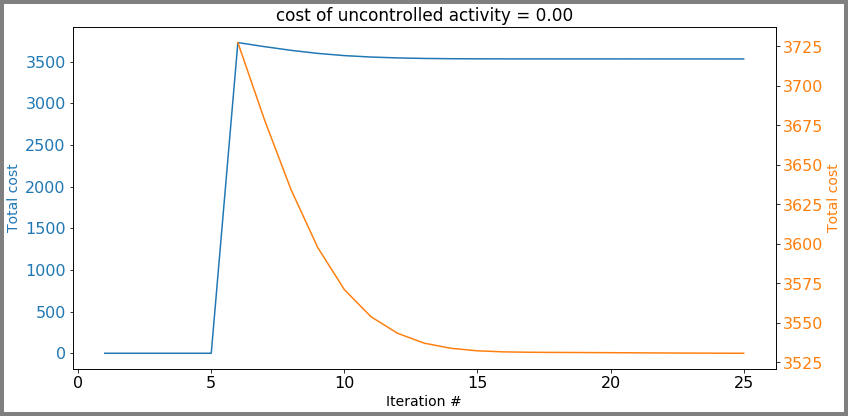

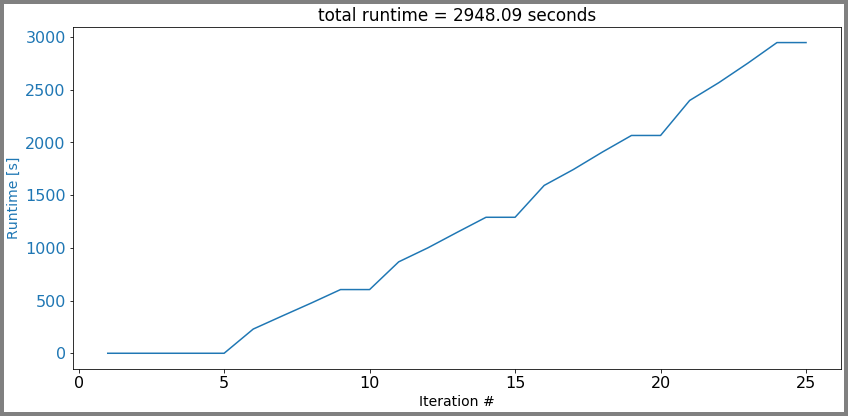

In [18]:
costA2 = np.array(costA2[:])
runtimeA2 = np.array(runtimeA2[:])
plotFunc.plot_convergence(costA2, path, str("p1_e1_u1nA_LowHigh_cost_" + alg) )
plotFunc.plot_runtime(runtimeA2, path, str("p1_e1_u1nA_LowHigh_runtime_" + alg))

cost A1 =  3529.8301171072785
cost A2 =  3530.745745865176
runtime A1 =  492.77352679999996
runtime A2 =  2948.0873721999997


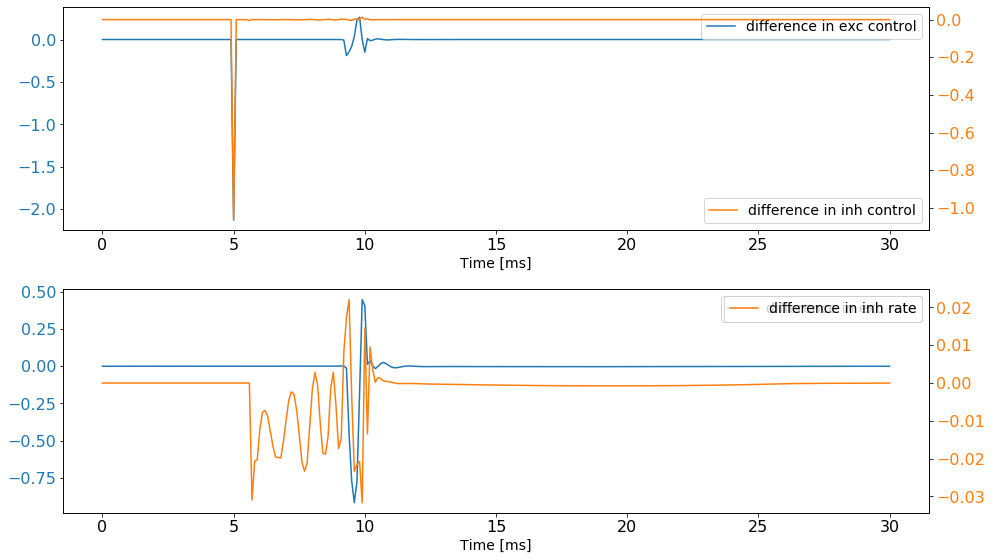

In [19]:
diff_cntrl = (cntrlA1_ - cntrlA2_)
diff_state = (bestStateA1_[:,:3,:] - bestStateA2_)
diff_cost = costA1[-1] - costA2[-1]
diff_runtime = runtimeA1[-1] - runtimeA2[-1]

print("cost A1 = ", costA1[-1])
print("cost A2 = ", costA2[-1])
print("runtime A1 = ", runtimeA1[-1])
print("runtime A2 = ", runtimeA2[-1])

fig, axes = plt.subplots(2, figsize=(14, 8))

color = 'tab:blue'
axes[0].set_xlabel('Time [ms]')
axes[0].plot(aln.t, diff_cntrl[0,0,:], label="difference in exc control", color=color)
axes[0].tick_params(axis='y', labelcolor=color)
axes[1].set_xlabel('Time [ms]')
axes[1].plot(aln.t, diff_state[0,0,:], label="difference in exc rate", color=color)
axes[1].tick_params(axis='y', labelcolor=color)

ax1 = axes[0].twinx() 
color = 'tab:orange'
ax1.plot(aln.t, diff_cntrl[0,1,:], label="difference in inh control", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = axes[1].twinx() 
color = 'tab:orange'
ax2.plot(aln.t, diff_state[0,1,:], label="difference in inh rate", color=color)
ax2.tick_params(axis='y', labelcolor=color)

for i in range(2):
    axes[i].legend()
ax1.legend()
ax2.legend()
    
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig(os.path.join(path,"p1_e1_u1nA_LowHigh_compare"))

In [ ]:
rate = aln.params.precalc_r
v = aln.params.precalc_V
tau = aln.params.precalc_tau_mu

ir = aln.params.Irange
sr = aln.params.sigmarange

def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

gradient_r = np.zeros(( len(ir), len(sr), 2 ))
gradient_v = np.zeros(( len(ir), len(sr), 2 ))
gradient_t = np.zeros(( len(ir), len(sr), 2 ))
for sigma in range(len(sr)-1):
    for mu in range(len(ir)-1):
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], rate)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], rate)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], v)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], v)
        gradient_v[mu, sigma, 0] = res0
        gradient_v[mu, sigma, 1] = res1
        res0 = jac_aln.der_mu_up(aln, sr[sigma], ir[mu], tau)
        res1 = jac_aln.der_sigma(aln, sr[sigma], ir[mu], tau)
        gradient_t[mu, sigma, 0] = res0
        gradient_t[mu, sigma, 1] = res1
        
